# Customer Churn Prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle as pkl
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve, classification_report)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

## 1) Load Data

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2) EDA

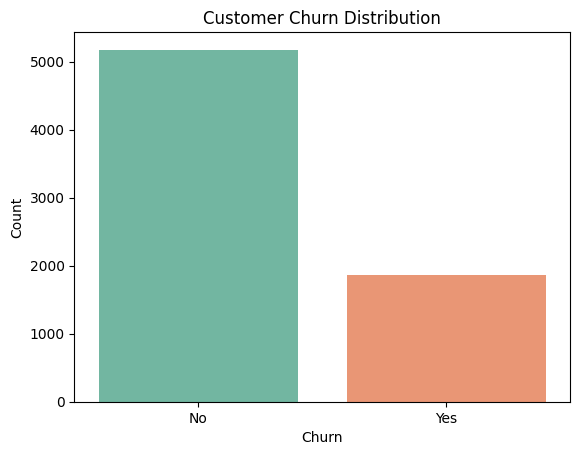

In [ ]:
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn'); plt.ylabel('Count')
plt.show()

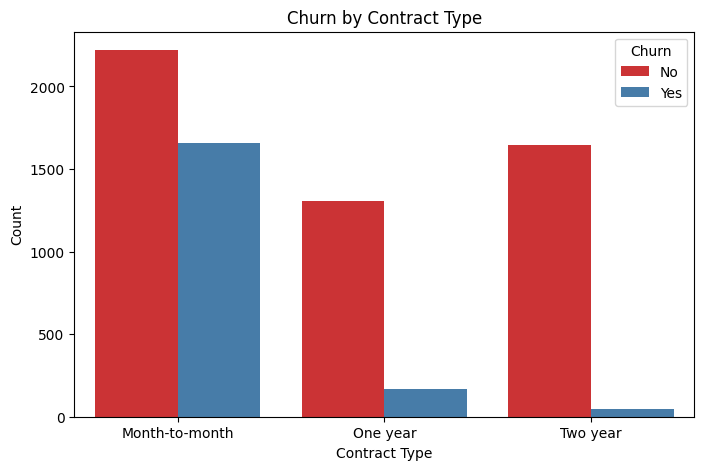

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type'); plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()

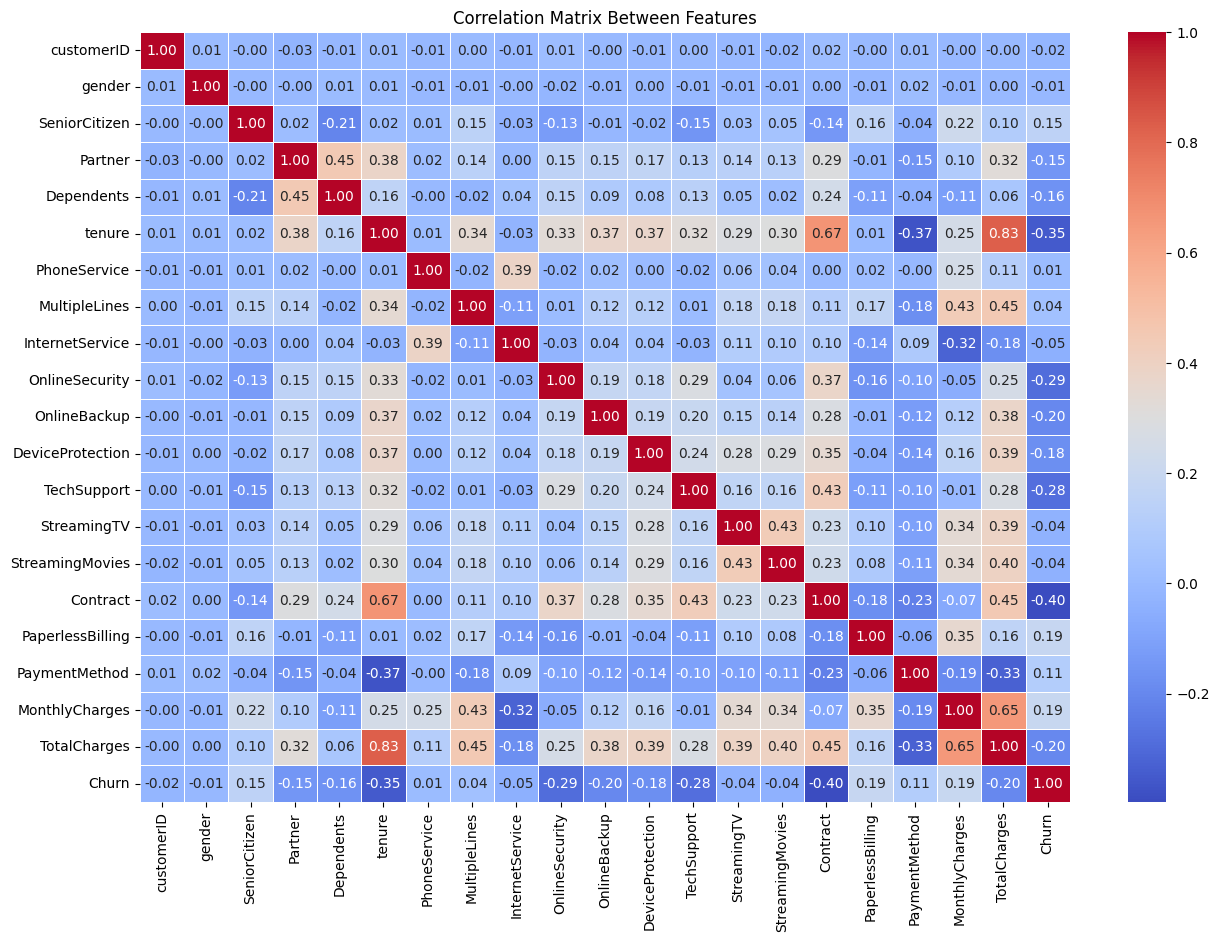

In [ ]:
# encode temporarily just for the correlation matrix / pairplot (not the modeling encoding)
df_temp = df.copy()
for col in df_temp.columns:
    if df_temp[col].dtype == 'object':
        df_temp[col] = df_temp[col].astype('category').cat.codes
df_temp['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

plt.figure(figsize=(15, 10))
corr = df_temp.corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Between Features")
plt.show()

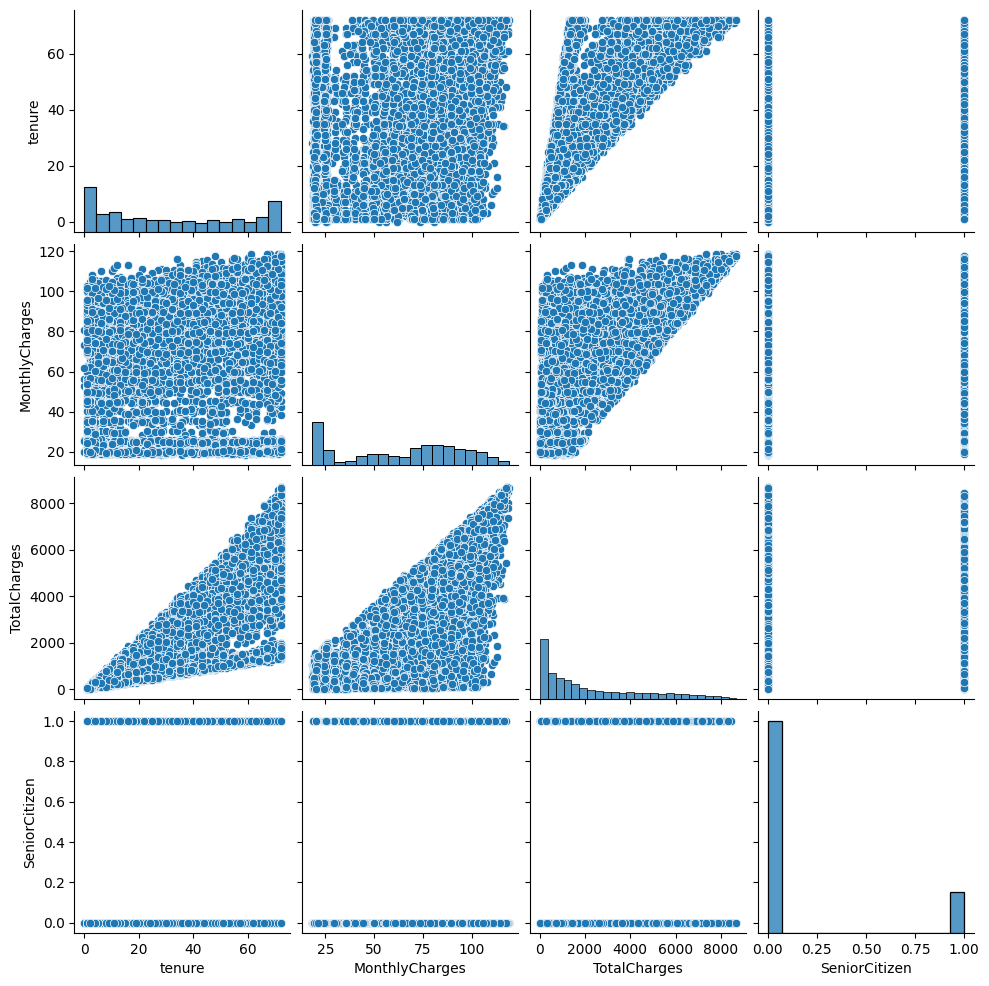

In [ ]:
sns.pairplot(df_temp[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']])
plt.show()

In [ ]:
fig = px.histogram(df, x="tenure", nbins=30, color="Churn", barmode='overlay', title="Distribution of Tenure by Churn")
fig.show()

In [ ]:
fig = px.box(df, x="Churn", y="MonthlyCharges", color="Churn", title="Monthly Charges vs Churn")
fig.show()

In [ ]:
fig = px.pie(df, names='Churn', title='Churn Distribution')
fig.show()

## 3) Data Cleaning

In [ ]:
df["Churn"] = df["Churn"].map({'Yes': 1, 'No': 0})
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("nulls in TotalCharges before fix:", df['TotalCharges'].isnull().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("nulls after fix:", df['TotalCharges'].isnull().sum())

nulls in TotalCharges before fix: 11
nulls after fix: 0


## 4) Feature Engineering + Encoding\n\nBinning + mapping

In [ ]:
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["Partner"] = le.fit_transform(df["Partner"])
df["Dependents"] = le.fit_transform(df["Dependents"])
df["PhoneService"] = le.fit_transform(df["PhoneService"])

df['MultipleLines'] = df['MultipleLines'].map({'Yes': 2, 'No': 1, 'No phone service': 0})
df["InternetService"] = df["InternetService"].map({"No": 0, "DSL": 1, "Fiber optic": 2})

for col in ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]:
    df[col] = df[col].map({"No": 2, "No internet service": 0, "Yes": 1})

df["PaperlessBilling"] = df["PaperlessBilling"].map({"No": 0, "Yes": 1})

df["Contract"] = df["Contract"].replace("Month-to-month", "Monthly")
df["Contract"] = df["Contract"].map({"One year": 0, "Two year": 1, "Monthly": 2})

df["PaymentMethod"] = df["PaymentMethod"].map({
    "Electronic check": 0, "Mailed check": 1,
    "Bank transfer (automatic)": 2, "Credit card (automatic)": 3
})

# tenure -> 4 bins
df.loc[df['tenure'] <= 20, 'tenure'] = 0
df.loc[(df['tenure'] > 20) & (df['tenure'] <= 40), 'tenure'] = 1
df.loc[(df['tenure'] > 40) & (df['tenure'] <= 60), 'tenure'] = 2
df.loc[df['tenure'] > 60, 'tenure'] = 3

# MonthlyCharges -> 4 bins
df.loc[df['MonthlyCharges'] <= 30, 'MonthlyCharges'] = 0
df.loc[(df['MonthlyCharges'] > 30) & (df['MonthlyCharges'] <= 60), 'MonthlyCharges'] = 1
df.loc[(df['MonthlyCharges'] > 60) & (df['MonthlyCharges'] <= 90), 'MonthlyCharges'] = 2
df.loc[df['MonthlyCharges'] > 90, 'MonthlyCharges'] = 3

# TotalCharges -> 4 bins
df.loc[df['TotalCharges'] <= 100, 'TotalCharges'] = 0
df.loc[(df['TotalCharges'] > 100) & (df['TotalCharges'] <= 400), 'TotalCharges'] = 1
df.loc[(df['TotalCharges'] > 400) & (df['TotalCharges'] <= 800), 'TotalCharges'] = 2
df.loc[df['TotalCharges'] > 800, 'TotalCharges'] = 3

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   int64  
 16  PaperlessBilling  7043 non-null   int64  


## 5) Train/Test Split + Class Imbalance (SMOTE) + Scaling

In [ ]:
df_model = df.drop('customerID', axis=1)

X = df_model.drop(['Churn'], axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_resampled.value_counts().to_dict())

Before SMOTE: {0: 3622, 1: 1308}
After SMOTE : {0: 3622, 1: 3622}


## 6) Model Training + Hyperparameter Tuning\n\nTries Logistic Regression, Random Forest, and SVC with `RandomizedSearchCV` (scoring=`f1`)

In [ ]:
candidates = {
    "logistic_regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"]}
    ),
    "random_forest": (
        RandomForestClassifier(random_state=42),
        {"n_estimators": [200, 400, 600], "max_depth": [None, 6, 10, 20], "min_samples_split": [2, 5, 10]}
    ),
    "svc": (
        SVC(probability=True, random_state=42),
        {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"], "gamma": ["scale", "auto"]}
    ),
}

best_model = None
best_name = None
best_score = -1

for name, (estimator, grid) in candidates.items():
    search = RandomizedSearchCV(estimator, param_distributions=grid, n_iter=10,
                                 scoring='f1', cv=3, random_state=42, n_jobs=-1)
    search.fit(X_train_scaled, y_train_resampled)
    print(f"[{name}] best CV f1: {search.best_score_:.4f} | params: {search.best_params_}")
    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_model = search.best_estimator_
        best_name = name

print(f"\nSelected model: {best_name} (CV f1={best_score:.4f})")
model = best_model

[logistic_regression] best CV f1: 0.7689 | params: {'penalty': 'l2', 'C': 0.01}
[random_forest] best CV f1: 0.8285 | params: {'n_estimators': 400, 'min_samples_split': 5, 'max_depth': 20}
[svc] best CV f1: 0.8126 | params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}

Selected model: random_forest (CV f1=0.8285)


## 7) Evaluation — Precision / Recall / F1 / ROC-AUC / Confusion Matrix

In [ ]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1:       ", f1_score(y_test, y_pred))
if y_proba is not None:
    print("ROC-AUC:  ", roc_auc_score(y_test, y_proba))

print("\n", classification_report(y_test, y_pred))

Precision: 0.5472560975609756
Recall:    0.6399286987522281
F1:        0.589975349219392
ROC-AUC:   0.8148292353492473

               precision    recall  f1-score   support

           0       0.86      0.81      0.83      1552
           1       0.55      0.64      0.59       561

    accuracy                           0.76      2113
   macro avg       0.70      0.72      0.71      2113
weighted avg       0.78      0.76      0.77      2113



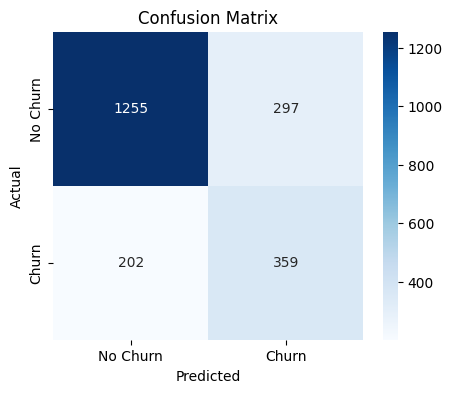

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

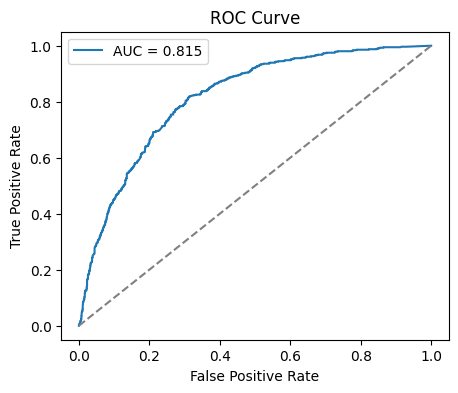

In [ ]:
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve"); plt.legend()
    plt.show()

## 8) Explainability — Feature Importance\n\nUses the model's built-in importance if available (e.g. Random Forest), otherwise falls back to permutation importance — works for any model, including SVC.

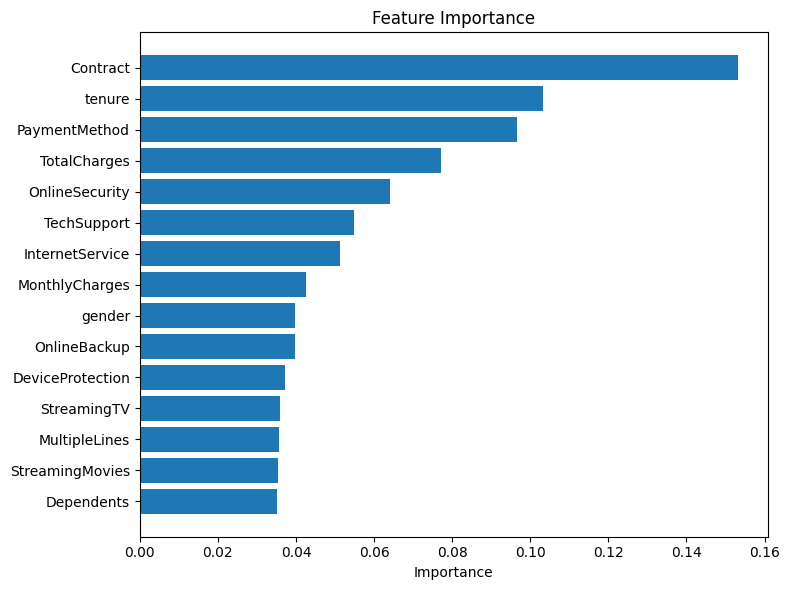

In [ ]:
feature_names = X.columns

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
else:
    perm = permutation_importance(model, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    importances = perm.importances_mean

order = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 6))
plt.barh(feature_names[order][:15][::-1], importances[order][:15][::-1])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## 9) Deployment

In [ ]:
with open('model.pkl', 'wb') as f:
    pkl.dump(model, f)

print("Model saved successfully!")

Model saved successfully!
